# Statistical Analysis - Mathematical Validation

This notebook focuses on rigorous mathematical analysis, including skewness/kurtosis profiling, hypothesis testing, and advanced feature engineering like Debt-to-Income (DTI) ratios.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm

from statsmodels.formula.api import ols

df = pd.read_csv('../data/processed/cleaned_loan_data.csv')
df.head()

,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10.0,Home Mortgage,debt consolidation,42000.83,21.8,0.0,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10.0,Home Mortgage,debt consolidation,36624.40,19.4,0.0,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2.0,Rent,debt consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10.0,Rent,debt consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10.0,Home Mortgage,debt consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


## 1. Descriptive Profiling: Shape of the Data
Evaluating Normality through Skewness and Kurtosis metrics.

In [2]:
numeric_cols = ['Current Loan Amount', 'Monthly Debt', 'Annual Income', 'Credit Score']
shape_metrics = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})

print("Distribution Shape Metrics:")
display(shape_metrics)

Distribution Shape Metrics:


,Skewness,Kurtosis
Current Loan Amount,0.631017,-0.796371
Monthly Debt,1.200296,1.781588
Annual Income,4.720015,53.159881
Credit Score,-1.655515,3.424382


## 2. Correlation Analysis
Understanding how numerical features interact with each other.

In [3]:
# Correcting DTI calculation: (Monthly Debt) / (Annual Income / 12)
df['DTI_Ratio'] = df['Monthly Debt'] / (df['Annual Income'] / 12)

print("DTI Ratio Summary Metrics:")
display(df['DTI_Ratio'].describe())

# Identifying High-Risk Applicants (DTI > 40%)
high_risk_count = len(df[df['DTI_Ratio'] > 0.4])
print(f"\nNumber of applicants with DTI > 40%: {high_risk_count} ({high_risk_count/len(df)*100:.2f}%)")

DTI Ratio Summary Metrics:


count    10000.000000
mean         0.175057
std          0.089882
min          0.000000
25%          0.110924
50%          0.168000
75%          0.229997
max          0.617350
Name: DTI_Ratio, dtype: float64


Number of applicants with DTI > 40%: 122 (1.22%)


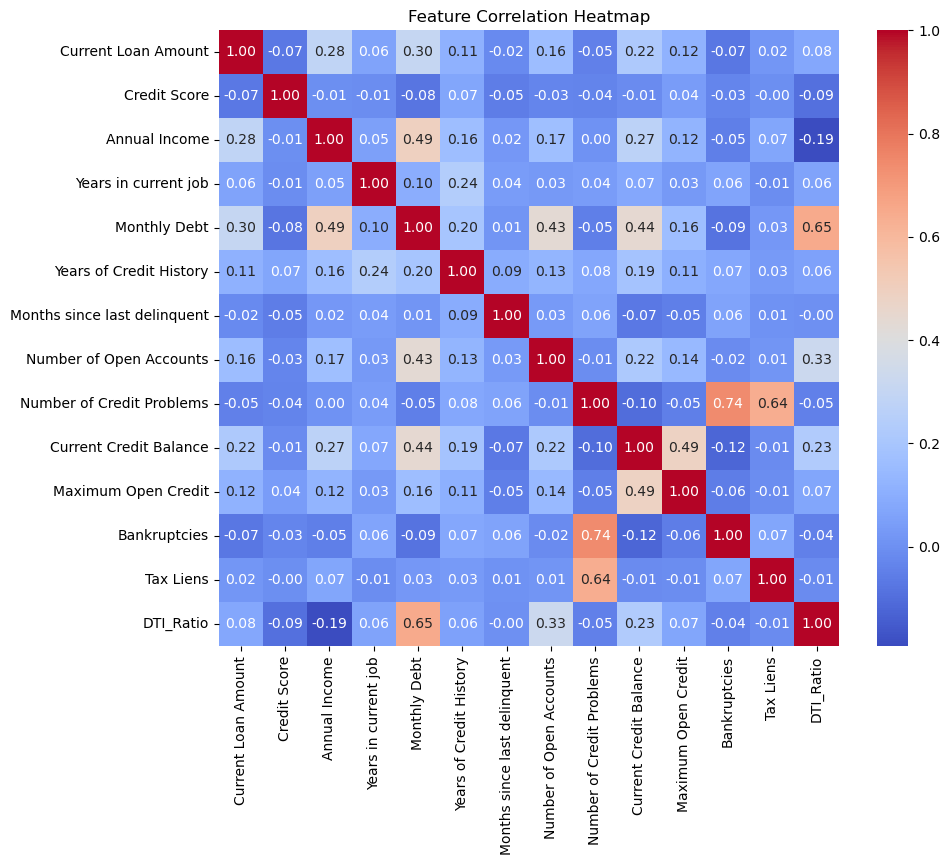

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()